In [1]:
# ============================================================
# LOAD MODULES AND MODEL OUTPUTS
# ============================================================
from Imports import *
from settings import *
from Inputs import *
from Helper import *
from PlotHelper import *
from Outputs import *

# --- Load MODFLOW 6 simulation ---
sim = flopy.mf6.MFSimulation.load(sim_ws=sim_ws, verbosity_level=0)
gwf = sim.get_model(nameModel)

# --- Model arrays from DIS package ---
top     = np.array(gwf.dis.top.array,     dtype=float)
botm    = np.array(gwf.dis.botm.array,    dtype=float)
idomain = np.array(gwf.dis.idomain.array, dtype=int)

# --- Grid properties ---
xorigin = float(gwf.modelgrid.xoffset)
yorigin = float(gwf.modelgrid.yoffset)
delr    = gwf.modelgrid.delr
delc    = gwf.modelgrid.delc
nlay, nrow, ncol = idomain.shape

# --- Head output: memory-efficient load (float32 disk-backed memmap) ---
# Full float64: ~38 GB for 312 × 8 × 1319 × 1527 → MemoryError on most machines
# float32 memmap: ~19 GB on disk; virtually zero RAM; downstream code unchanged.
hds   = bf.HeadFile(os.path.join(sim_ws, f"{nameModel}.hds"))
times = hds.get_times()

def _load_head_cached(sim_ws, nameModel, hds_obj=None, times=None):
    """Load all head timesteps as float32 memmap (disk-backed, low RAM).

    Full float64 load: ~38 GB for 312 periods × 8 layers × 1319 × 1527.
    float32 memmap  : ~19 GB on disk, virtually zero RAM until accessed.
    HDRY (>=1e20) is replaced with NaN during the one-time write pass.
    """
    import numpy as np, flopy.utils.binaryfile as _bf
    _hds = hds_obj or _bf.HeadFile(
        __import__('os').path.join(sim_ws, f"{nameModel}.hds"))
    _times = times if times is not None else _hds.get_times()
    _h0    = _hds.get_data(totim=_times[0])
    _nper  = len(_times)
    _shape = (_nper,) + _h0.shape          # (312, 8, 1319, 1527)
    _cache = __import__('os').path.join(sim_ws, "head_f32_cache.dat")

    if __import__('os').path.exists(_cache):
        _sz_gb = __import__('os').path.getsize(_cache) / 1e9
        print(f"Loading head from disk cache ({_sz_gb:.1f} GB float32 memmap)…")
        return np.memmap(_cache, dtype=np.float32, mode='r', shape=_shape), _times

    _needed_gb = _nper * _h0.size * 4 / 1e9
    print(f"Building float32 head cache  →  {_cache}  ({_needed_gb:.1f} GB)")
    _mm = np.memmap(_cache, dtype=np.float32, mode='w+', shape=_shape)
    for _i, _t in enumerate(_times):
        _h = _hds.get_data(totim=_t).astype(np.float32)
        _h[_h >= 1e20] = np.nan
        _mm[_i] = _h
        if (_i + 1) % 52 == 0:
            print(f"  cached {_i+1}/{_nper} periods…")
    _mm.flush()
    print("Head cache complete.")
    return _mm, _times

head, times = _load_head_cached(sim_ws, nameModel, hds_obj=hds, times=times)
dates  = pd.date_range(start=START_DATE, periods=len(times), freq="MS")
months = dates

print(f"Model loaded  : {nameModel}")
print(f"Head shape    : {head.shape}")
print(f"Date range    : {dates[0].strftime('%Y-%m')} to {dates[-1].strftime('%Y-%m')}")

# --- Load recharge stress period data ---
_rch_path = os.path.join(sim_ws, 'rch_spd.npz')
if os.path.exists(_rch_path):
    _rch = np.load(_rch_path)
    rch_spd = {int(k): _rch[k] for k in _rch.files}
    print(f'Loaded rch_spd: {len(rch_spd)} periods')
else:
    rch_spd = None
    print('WARNING: rch_spd.npz not found in sim_ws — recharge plots will be skipped')

PROJ_LIB = None
PROJ_DATA = None
numpy version: 2.4.3
matplotlib version: 3.10.9
flopy version: 3.9.5
Loading head from disk cache (12.6 GB float32 memmap)…
Model loaded  : Testing_1
Head shape    : (312, 5, 1319, 1527)
Date range    : 2000-01 to 2025-12


# This notebook will check the Simulations outputs and process the outputs

## 17) Optional: listing-file budget summary

This reads the MF6 listing file and prints the flux budget and percent discrepancy.

In [2]:
# ---------------------------------------------------------
# MODFLOW 6 budget from listing file  (fast tail approach)
# ---------------------------------------------------------
# The listing file for a 312-period run is ~64 GB.
# flopy.Mf6ListBudget.get_dataframes() parses the ENTIRE file => takes hours.
# This version seeks to the last ~500 KB and prints the final budget table.
# ---------------------------------------------------------
lst_path = os.path.join(sim_ws, f"{nameModel}.lst")
print(f'Listing file: {os.path.getsize(lst_path)/1e9:.2f} GB')

def _read_lst_tail(path, n_bytes=500_000):
    sz = os.path.getsize(path)
    with open(path, 'rb') as _f:
        _f.seek(max(0, sz - n_bytes))
        return _f.read().decode('utf-8', errors='replace')

_tail       = _read_lst_tail(lst_path, n_bytes=500_000)
_tail_lines = _tail.splitlines()

# -- Simulation status --------------------------------------------------------
_term = [l for l in _tail_lines
         if 'termination' in l.lower() or 'Normal' in l or 'ERROR' in l.upper()]
print('=== SIMULATION STATUS ===')
for l in _term:
    print(l)

# -- Last budget table: search back for 'VOLUMETRIC BUDGET' or 'TOTAL IN' -----
_bstart = None
for _i in range(len(_tail_lines) - 1, -1, -1):
    if 'VOLUMETRIC BUDGET' in _tail_lines[_i].upper():
        _bstart = _i
        break
# Fallback: find last 'TOTAL IN' and back up 10 lines for context
if _bstart is None:
    for _i in range(len(_tail_lines) - 1, -1, -1):
        if 'TOTAL IN' in _tail_lines[_i].upper():
            _bstart = max(0, _i - 10)
            break

print('\n=== FINAL PERIOD — VOLUMETRIC BUDGET ===')
if _bstart is not None:
    print('\n'.join(_tail_lines[_bstart:_bstart + 70]))
else:
    print('Budget table not found — printing last 50 lines of listing file:')
    print('\n'.join(_tail_lines[-50:]))

# -- Percent discrepancy ------------------------------------------------------
_disc = [l.strip() for l in _tail_lines
         if 'PERCENT' in l.upper() and 'DISCREPANCY' in l.upper()]
print('\n=== PERCENT DISCREPANCY ===')
if _disc:
    for l in _disc:
        print(l)
else:
    print('No PERCENT DISCREPANCY lines found — increase n_bytes in _read_lst_tail')

# -- Time summary (last period) -----------------------------------------------
_tstart = None
for _i in range(len(_tail_lines) - 1, -1, -1):
    if 'TIME SUMMARY' in _tail_lines[_i].upper():
        _tstart = _i
        break
if _tstart is not None:
    print('\n=== TIME SUMMARY ===')
    print('\n'.join(_tail_lines[_tstart:_tstart + 12]))

# -- Optional full parse (WARNING: very slow on 64 GB file) -------------------
# mf_list = flopy.utils.Mf6ListBudget(lst_path)
# df_flux, df_vol = mf_list.get_dataframes(start_datetime=START_DATE, diff=True)
# print(df_flux.to_string())

Listing file: 0.00 GB
=== SIMULATION STATUS ===

=== FINAL PERIOD — VOLUMETRIC BUDGET ===
     ------------------                 ------------------------                     ----------------

           IN:                                      IN:
           ---                                      ---
              STO-SS =  5752460245.6585                STO-SS =      417789.3477     STORAGE                          
              STO-SY =377134522232.3909                STO-SY =    39975095.8040     STORAGE                          
                 DRN =           0.0000                   DRN =           0.0000     DRN                              
                 GHB =       1.3797E+12                   GHB =   149571272.1543     GHB_GL                           
                RCHA =       2.4021E+12                  RCHA =   116568065.7869     RCHA                             

            TOTAL IN =       4.1647E+12              TOTAL IN =   306532223.0928

          OUT:   

## 18) Optional: example post-processing

The original notebook had many exploratory post-processing cells.  
This notebook keeps one representative post-processing figure cell as a starting point.

In [5]:
rch_spd = r"D:\Users\abolmaal\modelling\Modflow\Testing_1\rch_spd.npz"

Average DTW after cleaning:
  min  : -38.20 m
  p5   : 0.10 m
  p50  : 0.50 m
  p95  : 26.84 m
  max  : 197.26 m
  negative cells : 5530
  cells > 50 m   : 19,983
  cells > 100 m  : 4,857
Auto-loaded rch_spd: 312 periods from {0: array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(1319, 1527), dtype=float32), 1: array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(1319, 1527), dtype=float32), 2: array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [

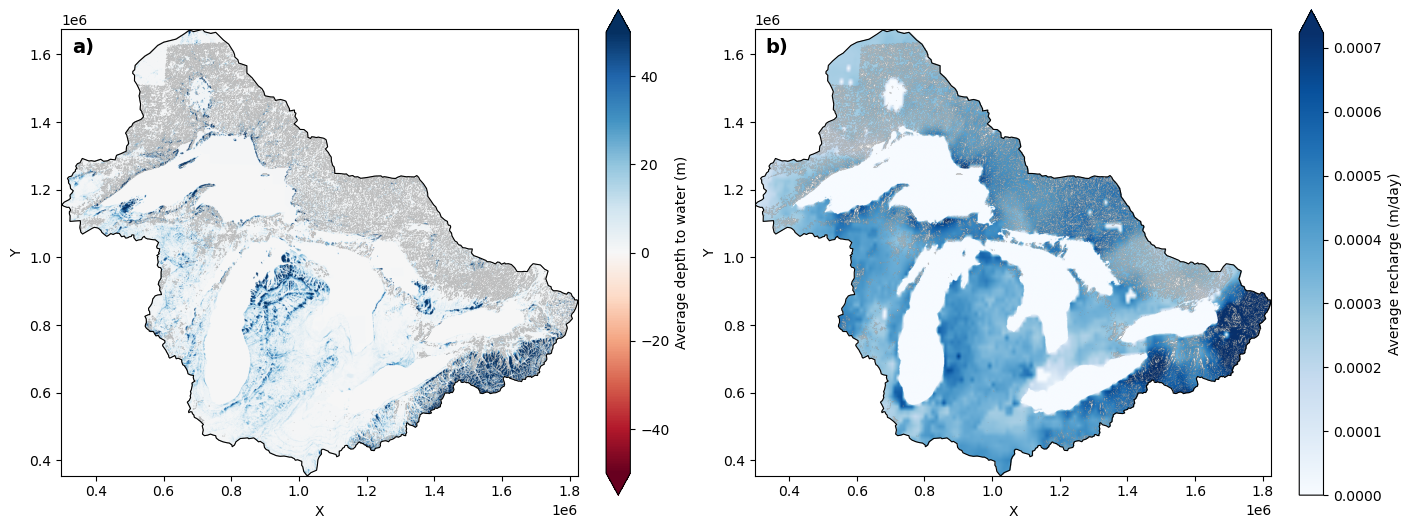

Saved: D:\Users\abolmaal\modelling\Figs\Testing_1\avg_dtw_avg_recharge_studyperiod.png
Average DTW min/max: -38.200802691187825 197.2560941910438
Average recharge min/max: 0.0 0.0011310440304208524


In [6]:
# ============================================================
# SETTINGS
# ============================================================
save_fig = True
out_fig = os.path.join(fig_dir, "avg_dtw_avg_recharge_studyperiod.png")

# if head is not already loaded — use disk-backed float32 memmap (low RAM)
if "head" not in globals() or head is None:
    if "_load_head_cached" not in dir():
        def _load_head_cached(sim_ws, nameModel, hds_obj=None, times=None):
            """Load all head timesteps as float32 memmap (disk-backed, low RAM).
        
            Full float64 load: ~38 GB for 312 periods × 8 layers × 1319 × 1527.
            float32 memmap  : ~19 GB on disk, virtually zero RAM until accessed.
            HDRY (>=1e20) is replaced with NaN during the one-time write pass.
            """
            import numpy as np, flopy.utils.binaryfile as _bf
            _hds = hds_obj or _bf.HeadFile(
                __import__('os').path.join(sim_ws, f"{nameModel}.hds"))
            _times = times if times is not None else _hds.get_times()
            _h0    = _hds.get_data(totim=_times[0])
            _nper  = len(_times)
            _shape = (_nper,) + _h0.shape          # (312, 8, 1319, 1527)
            _cache = __import__('os').path.join(sim_ws, "head_f32_cache.dat")
        
            if __import__('os').path.exists(_cache):
                _sz_gb = __import__('os').path.getsize(_cache) / 1e9
                print(f"Loading head from disk cache ({_sz_gb:.1f} GB float32 memmap)…")
                return np.memmap(_cache, dtype=np.float32, mode='r', shape=_shape), _times
        
            _needed_gb = _nper * _h0.size * 4 / 1e9
            print(f"Building float32 head cache  →  {_cache}  ({_needed_gb:.1f} GB)")
            _mm = np.memmap(_cache, dtype=np.float32, mode='w+', shape=_shape)
            for _i, _t in enumerate(_times):
                _h = _hds.get_data(totim=_t).astype(np.float32)
                _h[_h >= 1e20] = np.nan
                _mm[_i] = _h
                if (_i + 1) % 52 == 0:
                    print(f"  cached {_i+1}/{_nper} periods…")
            _mm.flush()
            print("Head cache complete.")
            return _mm, _times
    head, times = _load_head_cached(sim_ws, nameModel)
    print("Loaded head array:", head.shape, head.dtype)

# top from model
top = np.array(gwf.dis.top.array, dtype=float)

# ============================================================
# HELPERS
# ============================================================

# ============================================================
# 1) AVERAGE DEPTH TO WATER
# ============================================================
# =========================================================
# COMPUTE DTW — with dry cell protection
# =========================================================

# Compute avg_dtw with an incremental running sum — avoids allocating a
# (312, 1319, 1527) float64 contiguous block (~4.68 GB) plus its nanmean copy.
# dtw_all is stored as a list of float32 slices (~2.34 GB total, non-contiguous).
_dtw_sum = np.zeros((nrow, ncol), dtype=np.float64)
_dtw_cnt = np.zeros((nrow, ncol), dtype=np.int32)
dtw_all  = []

for i in range(head.shape[0]):
    wt  = get_water_table(head[i], idomain, huge=1e29)
    dtw = np.array(top, dtype=float) - wt

    # hard clip: anything beyond physical bounds is a dry cell artifact
    # Great Lakes Basin: no cell should have DTW > total aquifer thickness (~500 m max)
    dtw = np.where(dtw > 200,  np.nan, dtw)   # dry/inactive artifact
    dtw = np.where(dtw < -50,  np.nan, dtw)   # head >50 m above surface: numerical artifact
    dtw = np.where(idomain[0] <= 0, np.nan, dtw)

    dtw_all.append(dtw.astype(np.float32))   # float32 halves per-slice RAM

    # accumulate for mean — no large intermediate array needed
    _valid = np.isfinite(dtw)
    _dtw_sum[_valid] += dtw[_valid]
    _dtw_cnt[_valid] += 1

# average — same result as nanmean, no extra 4.68 GB allocation
avg_dtw = np.where(_dtw_cnt > 0, _dtw_sum / _dtw_cnt, np.nan)
del _dtw_sum, _dtw_cnt

# mask inactive cells
avg_dtw = np.where(idomain[0] > 0, avg_dtw, np.nan)

# mask lake cells
if "lake_mask_2d" in globals():
    avg_dtw = np.where(lake_mask_2d, np.nan, avg_dtw)

# ---- final stats ----
finite = avg_dtw[np.isfinite(avg_dtw)]
print("Average DTW after cleaning:")
print(f"  min  : {np.nanmin(finite):.2f} m")
print(f"  p5   : {np.percentile(finite, 5):.2f} m")
print(f"  p50  : {np.percentile(finite, 50):.2f} m")
print(f"  p95  : {np.percentile(finite, 95):.2f} m")
print(f"  max  : {np.nanmax(finite):.2f} m")
print(f"  negative cells : {int(np.sum(finite < 0))}")
print(f"  cells > 50 m   : {int(np.sum(finite > 50)):,}")
print(f"  cells > 100 m  : {int(np.sum(finite > 100)):,}")
# ============================================================
# 2) AVERAGE RECHARGE
# ============================================================
# Auto-load if rch_spd is a file path string (e.g. set by savez call)
if isinstance(rch_spd, str) and rch_spd.endswith(".npz") and os.path.exists(rch_spd):
    _rch = np.load(rch_spd)
    rch_spd = {int(k): _rch[k] for k in _rch.files}
    print(f"Auto-loaded rch_spd: {len(rch_spd)} periods from {rch_spd}")
if rch_spd is None:
    avg_rch = None
    print("WARNING: rch_spd not available — recharge subplot will be blank")
elif isinstance(rch_spd, dict):
    rch_arrays = []
    for per in sorted(rch_spd.keys()):
        arr = np.array(rch_spd[per], dtype=float)
        if arr.ndim == 3:
            arr = arr[0]
        rch_arrays.append(arr)
    rch_all  = np.array(rch_arrays, dtype=float)
    avg_rch  = np.nanmean(rch_all, axis=0)
    avg_rch  = np.where(idomain[0] > 0, avg_rch, np.nan)
else:
    arr = np.array(rch_spd, dtype=float)
    if arr.ndim == 3:
        rch_all = arr
    elif arr.ndim == 2:
        rch_all = arr[np.newaxis, :, :]
    else:
        avg_rch = None
        print(f"WARNING: rch_spd shape {getattr(np.array(rch_spd),'shape','?')} unsupported — recharge subplot blank")
        rch_all = None
    if rch_all is not None:
        avg_rch = np.nanmean(rch_all, axis=0)
        avg_rch = np.where(idomain[0] > 0, avg_rch, np.nan)

# ============================================================
# 3) COLOR LIMITS
# ============================================================
dtw_vmin, dtw_vmax = robust_limits(avg_dtw, qlow=2, qhigh=98, symmetric=True)
dtw_vmin = -50.0    # artesian / head above land
dtw_vmax =  50.0    # max realistic DTW for Great Lakes Basin
dtw_norm = TwoSlopeNorm(vmin=dtw_vmin, vcenter=0.0, vmax=dtw_vmax)

if avg_rch is not None:
    rch_vmin, rch_vmax = robust_limits(avg_rch, qlow=2, qhigh=98, symmetric=False)
else:
    rch_vmin, rch_vmax = 0.0, 1.0   # dummy — subplot will show "not available"

# ============================================================
# 4) BOUNDARY
# ============================================================
gdf_bdry = gpd.read_file(boundary_shp)
try:
    if getattr(gwf.modelgrid, "crs", None) is not None:
        gdf_bdry = gdf_bdry.to_crs(gwf.modelgrid.crs)
except Exception:
    pass

extent = get_extent(xorigin, yorigin, delr, delc, nrow, ncol)

# ============================================================
# 5) PLOT
# ============================================================
# ============================================================
# 5) PLOT
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

# ---- Average DTW
ax = axes[0]
im1 = ax.imshow(
    np.ma.masked_invalid(avg_dtw),
    origin="upper",
    extent=extent,
    cmap="RdBu",
    norm=dtw_norm,
)
gdf_bdry.boundary.plot(ax=ax, color="black", linewidth=0.8)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.text(
    0.02, 0.98, "a)",
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=14, fontweight="bold"
)
cbar1 = fig.colorbar(im1, ax=ax, shrink=0.82, extend="both")
cbar1.set_label("Average depth to water (m)")

# ---- Average Recharge
ax = axes[1]
if avg_rch is not None:
    im2 = ax.imshow(
        np.ma.masked_invalid(avg_rch),
        origin="upper",
        extent=extent,
        cmap="Blues",
        vmin=rch_vmin,
        vmax=rch_vmax,
    )
    gdf_bdry.boundary.plot(ax=ax, color="black", linewidth=0.8)
    cbar2 = fig.colorbar(im2, ax=ax, shrink=0.82, extend="max")
    cbar2.set_label("Average recharge (m/day)")
else:
    ax.set_facecolor("#eeeeee")
    ax.text(0.5, 0.5, "Recharge not available",
            transform=ax.transAxes, ha="center", va="center",
            fontsize=12, color="#888888")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.text(0.02, 0.98, "b)", transform=ax.transAxes,
        ha="left", va="top", fontsize=14, fontweight="bold")

plt.show()

if save_fig:
    fig.savefig(out_fig, dpi=300, bbox_inches="tight")
    print("Saved:", out_fig)

# ============================================================
# 6) SUMMARY
# ============================================================
print("Average DTW min/max:", np.nanmin(avg_dtw), np.nanmax(avg_dtw))
if avg_rch is not None:
    print("Average recharge min/max:", np.nanmin(avg_rch), np.nanmax(avg_rch))
else:
    print("Average recharge: not available")

HDS exists: True D:\Users\abolmaal\modelling\Modflow\Testing_1\Testing_1.hds
CBB exists: True D:\Users\abolmaal\modelling\Modflow\Testing_1\Testing_1.cbb
LST exists: True D:\Users\abolmaal\modelling\Modflow\Testing_1\Testing_1.lst
Number of saved times: 312
kstpkper list: [(np.int32(0), np.int32(0)), (np.int32(0), np.int32(1)), (np.int32(0), np.int32(2)), (np.int32(0), np.int32(3)), (np.int32(0), np.int32(4)), (np.int32(0), np.int32(5)), (np.int32(0), np.int32(6)), (np.int32(0), np.int32(7)), (np.int32(0), np.int32(8)), (np.int32(0), np.int32(9)), (np.int32(0), np.int32(10)), (np.int32(0), np.int32(11)), (np.int32(0), np.int32(12)), (np.int32(0), np.int32(13)), (np.int32(0), np.int32(14)), (np.int32(0), np.int32(15)), (np.int32(0), np.int32(16)), (np.int32(0), np.int32(17)), (np.int32(0), np.int32(18)), (np.int32(0), np.int32(19)), (np.int32(0), np.int32(20)), (np.int32(0), np.int32(21)), (np.int32(0), np.int32(22)), (np.int32(0), np.int32(23)), (np.int32(0), np.int32(24)), (np.int32(0

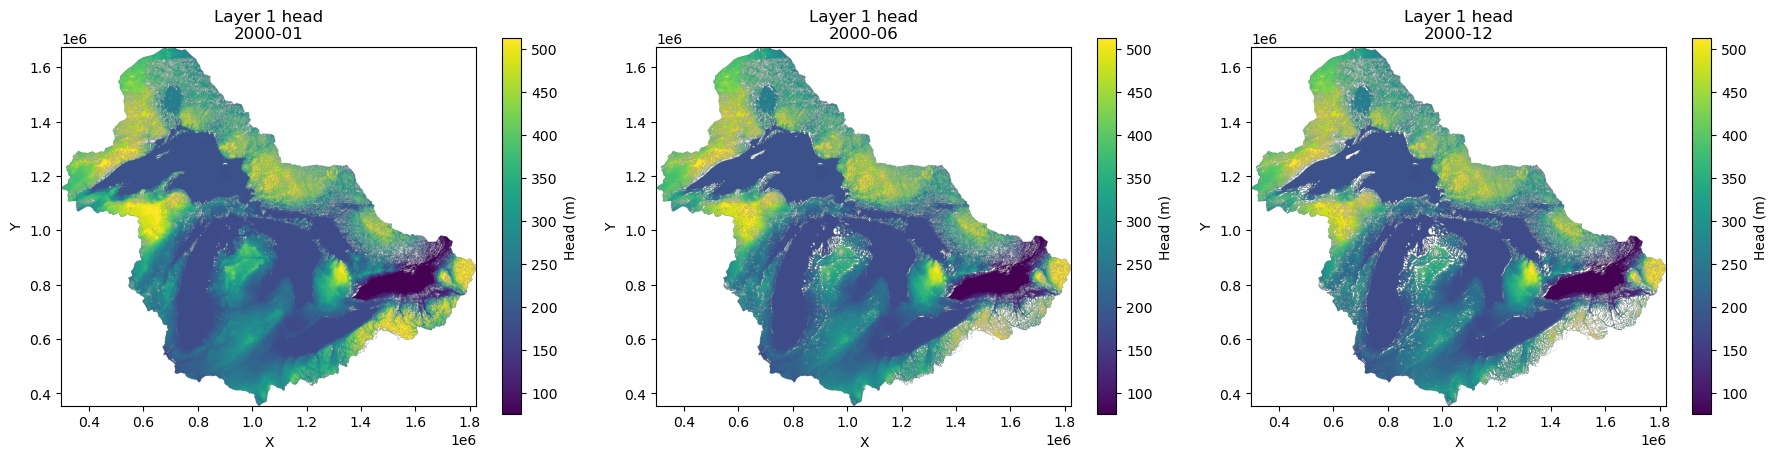

Water table plot vmin/vmax: 74.73399942297931 515.7683281660853


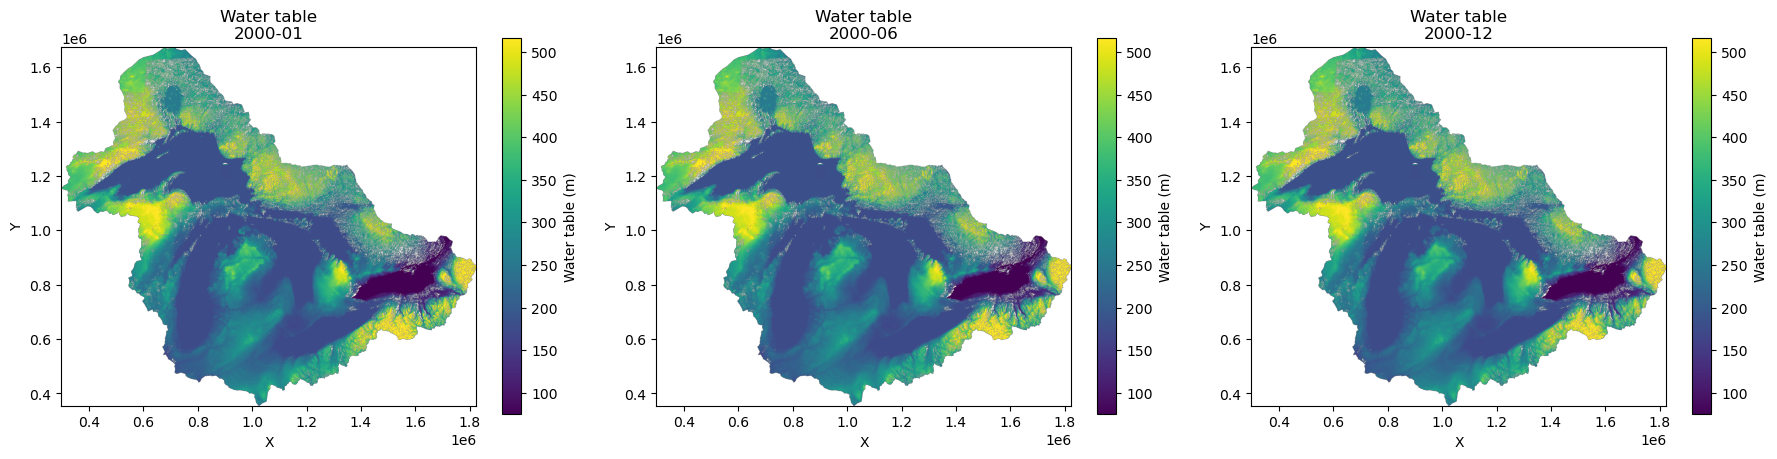

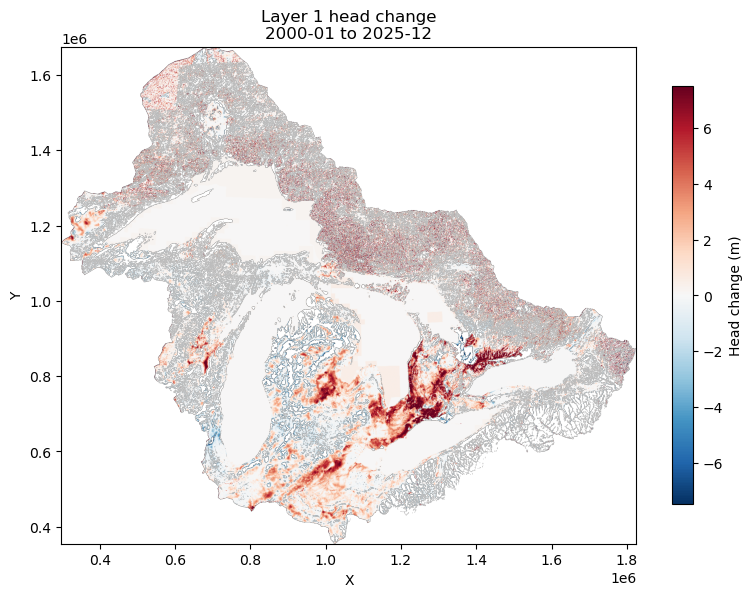


Head change min/max (m): -30.41057586448693 455876.2570476392


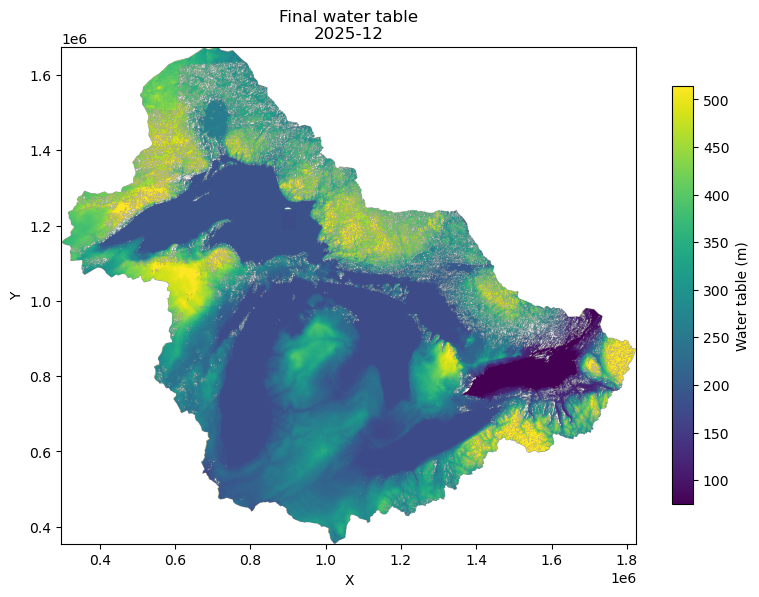

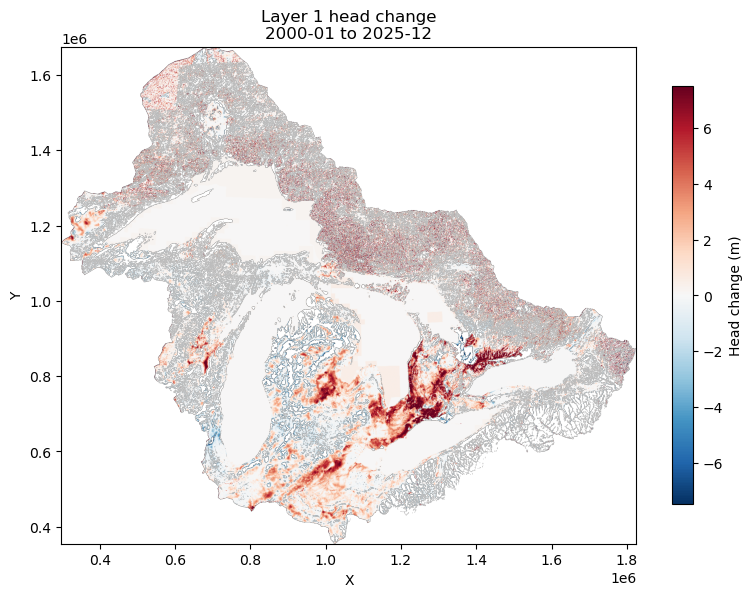


Saved figures to: D:\Users\abolmaal\modelling\Figs\Testing_1


In [7]:

# =========================================================
# 1) Paths to model outputs
# =========================================================
hds_path = Path(sim_ws) / f"{nameModel}.hds"
cbb_path = Path(sim_ws) / f"{nameModel}.cbb"
lst_path = Path(sim_ws) / f"{nameModel}.lst"

print("HDS exists:", hds_path.exists(), hds_path)
print("CBB exists:", cbb_path.exists(), cbb_path)
print("LST exists:", lst_path.exists(), lst_path)

assert hds_path.exists(), f"Head file not found: {hds_path}"


# =========================================================
# 2) Open head file and inspect saved times
# =========================================================
hdobj = flopy.utils.HeadFile(hds_path)
kstpkper_list = hdobj.get_kstpkper()
times = hdobj.get_times()

print("Number of saved times:", len(times))
print("kstpkper list:", kstpkper_list)

extent = get_extent(xorigin, yorigin, delr, delc, nrow, ncol)
date_labels = get_date_labels(len(kstpkper_list), months=months if "months" in globals() else None)


# =========================================================
# 3) Quick diagnostics: raw vs masked ranges
# =========================================================
print("\n--- HEAD DIAGNOSTICS ---")
for i, kp in enumerate(kstpkper_list):
    h = hdobj.get_data(kstpkper=kp)
    h0_raw = np.array(h[0], dtype=float)
    h0 = mask_model_array(h[0], idomain_layer=idomain[0], huge=1e20)

    print(f"{date_labels[i]}:")
    print("   raw min/max   =", np.nanmin(h0_raw), np.nanmax(h0_raw))
    if np.isfinite(h0).any():
        print("   masked min/max=", np.nanmin(h0), np.nanmax(h0))
        print("   finite count  =", np.isfinite(h0).sum())
    else:
        print("   masked array has no finite values")


# =========================================================
# 4) Summary statistics table for layer 1 heads
# =========================================================
stats = []
for i, kp in enumerate(kstpkper_list):
    h = hdobj.get_data(kstpkper=kp)
    h0 = mask_model_array(h[0], idomain_layer=idomain[0], huge=1e20)

    stats.append({
        "stress_period": i + 1,
        "label": date_labels[i],
        "min_head_L1": np.nanmin(h0),
        "max_head_L1": np.nanmax(h0),
        "mean_head_L1": np.nanmean(h0),
        "std_head_L1": np.nanstd(h0),
    })

df_stats = pd.DataFrame(stats)
print("\n--- LAYER 1 HEAD STATS ---")
print(df_stats)


# =========================================================
# 5) Plot layer 1 heads for selected stress periods
# =========================================================
# choose which stress periods to show
plot_ids = [0, 5, 11]   # first, middle, last for a 12-month run
plot_ids = [i for i in plot_ids if i < len(kstpkper_list)]

head_arrays = []
for idx in plot_ids:
    h = hdobj.get_data(kstpkper=kstpkper_list[idx])
    h0 = mask_model_array(h[0], idomain_layer=idomain[0], huge=1e20)
    head_arrays.append(h0)

vmin, vmax = robust_limits(head_arrays, qlow=2, qhigh=98)
print("\nHead plot vmin/vmax:", vmin, vmax)

fig, axes = plt.subplots(1, len(plot_ids), figsize=(6 * len(plot_ids), 5), squeeze=False)

for ax, idx, arr in zip(axes.flat, plot_ids, head_arrays):
    im = ax.imshow(
        np.ma.masked_invalid(arr),
        origin="upper",
        extent=extent,
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_title(f"Layer 1 head\n{date_labels[idx]}")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    plt.colorbar(im, ax=ax, shrink=0.8, label="Head (m)")

plt.tight_layout()
plt.show()


# =========================================================
# 6) Plot water table for selected stress periods
# =========================================================
wt_arrays = []
for idx in plot_ids:
    h = hdobj.get_data(kstpkper=kstpkper_list[idx])
    wt = get_water_table(h, idomain, huge=1e20)
    wt_arrays.append(wt)

vmin, vmax = robust_limits(wt_arrays, qlow=2, qhigh=98)
print("Water table plot vmin/vmax:", vmin, vmax)

fig, axes = plt.subplots(1, len(plot_ids), figsize=(6 * len(plot_ids), 5), squeeze=False)

for ax, idx, arr in zip(axes.flat, plot_ids, wt_arrays):
    im = ax.imshow(
        np.ma.masked_invalid(arr),
        origin="upper",
        extent=extent,
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_title(f"Water table\n{date_labels[idx]}")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    plt.colorbar(im, ax=ax, shrink=0.8, label="Water table (m)")

plt.tight_layout()
plt.show()


# =========================================================
# 7) Plot head change from first to last stress period
# =========================================================
h_first = hdobj.get_data(kstpkper=kstpkper_list[0])
h_last  = hdobj.get_data(kstpkper=kstpkper_list[-1])

h_first_L1 = mask_model_array(h_first[0], idomain_layer=idomain[0], huge=1e20)
h_last_L1  = mask_model_array(h_last[0],  idomain_layer=idomain[0], huge=1e20)

dh = h_last_L1 - h_first_L1

finite_dh = dh[np.isfinite(dh)]
if finite_dh.size > 0:
    lim = np.nanpercentile(np.abs(finite_dh), 98)
else:
    lim = 1.0

plt.figure(figsize=(8, 6))
plt.imshow(
    np.ma.masked_invalid(dh),
    origin="upper",
    extent=extent,
    cmap="RdBu_r",
    vmin=-lim,
    vmax=lim,
)
plt.colorbar(shrink=0.8, label="Head change (m)")
plt.title(f"Layer 1 head change\n{date_labels[0]} to {date_labels[-1]}")
plt.xlabel("X")
plt.ylabel("Y")
plt.tight_layout()
plt.show()

print("\nHead change min/max (m):", np.nanmin(dh), np.nanmax(dh))



# =========================================================
# 8) Save final figures
# =========================================================
fig_dir = Path(r"D:\Users\abolmaal\modelling\Figs\Testing_1")
fig_dir.mkdir(exist_ok=True)

# final water table
wt_last = get_water_table(h_last, idomain, huge=1e20)

plt.figure(figsize=(8, 6))
plt.imshow(
    np.ma.masked_invalid(wt_last),
    origin="upper",
    extent=extent,
    cmap="viridis",
    vmin=np.nanpercentile(wt_last[np.isfinite(wt_last)], 2),
    vmax=np.nanpercentile(wt_last[np.isfinite(wt_last)], 98),
)
plt.colorbar(shrink=0.8, label="Water table (m)")
plt.title(f"Final water table\n{date_labels[-1]}")
plt.xlabel("X")
plt.ylabel("Y")
plt.tight_layout()
plt.savefig(fig_dir / "final_water_table.png", dpi=300, bbox_inches="tight")
plt.show()

# head change
plt.figure(figsize=(8, 6))
plt.imshow(
    np.ma.masked_invalid(dh),
    origin="upper",
    extent=extent,
    cmap="RdBu_r",
    vmin=-lim,
    vmax=lim,
)
plt.colorbar(shrink=0.8, label="Head change (m)")
plt.title(f"Layer 1 head change\n{date_labels[0]} to {date_labels[-1]}")
plt.xlabel("X")
plt.ylabel("Y")
plt.tight_layout()
plt.savefig(fig_dir / "head_change_layer1.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nSaved figures to:", fig_dir)

In [ ]:

# ------------------------------------------------------------
# READ HEAD OUTPUT AFTER A SUCCESSFUL RUN
# ------------------------------------------------------------
headfile = os.path.join(sim_ws, f"{nameModel}.hds")

if not os.path.exists(headfile):
    raise FileNotFoundError(
        f"Head file not found: {headfile}\n"
        "Make sure Cell 12 finished with Run success: True before plotting."
    )

hds = flopy.utils.HeadFile(headfile)

# all output times
times = hds.get_times()
print("Number of output times:", len(times))
print("First/last output time:", times[0], times[-1])

# read all heads — float32 disk-backed memmap avoids 38 GB RAM requirement
if "_load_head_cached" not in dir():
    def _load_head_cached(sim_ws, nameModel, hds_obj=None, times=None):
        """Load all head timesteps as float32 memmap (disk-backed, low RAM).
    
        Full float64 load: ~38 GB for 312 periods × 8 layers × 1319 × 1527.
        float32 memmap  : ~19 GB on disk, virtually zero RAM until accessed.
        HDRY (>=1e20) is replaced with NaN during the one-time write pass.
        """
        import numpy as np, flopy.utils.binaryfile as _bf
        _hds = hds_obj or _bf.HeadFile(
            __import__('os').path.join(sim_ws, f"{nameModel}.hds"))
        _times = times if times is not None else _hds.get_times()
        _h0    = _hds.get_data(totim=_times[0])
        _nper  = len(_times)
        _shape = (_nper,) + _h0.shape          # (312, 8, 1319, 1527)
        _cache = __import__('os').path.join(sim_ws, "head_f32_cache.dat")
    
        if __import__('os').path.exists(_cache):
            _sz_gb = __import__('os').path.getsize(_cache) / 1e9
            print(f"Loading head from disk cache ({_sz_gb:.1f} GB float32 memmap)…")
            return np.memmap(_cache, dtype=np.float32, mode='r', shape=_shape), _times
    
        _needed_gb = _nper * _h0.size * 4 / 1e9
        print(f"Building float32 head cache  →  {_cache}  ({_needed_gb:.1f} GB)")
        _mm = np.memmap(_cache, dtype=np.float32, mode='w+', shape=_shape)
        for _i, _t in enumerate(_times):
            _h = _hds.get_data(totim=_t).astype(np.float32)
            _h[_h >= 1e20] = np.nan
            _mm[_i] = _h
            if (_i + 1) % 52 == 0:
                print(f"  cached {_i+1}/{_nper} periods…")
        _mm.flush()
        print("Head cache complete.")
        return _mm, _times
head, times = _load_head_cached(sim_ws, nameModel, hds_obj=hds, times=times)

# dates matching TDIS monthly periods
dates = pd.date_range(start=START_DATE, periods=head.shape[0], freq="MS")

print("head shape:", head.shape)
print("dates:", dates[0], "to", dates[-1])

# optional plot index for selected maps
max_maps = min(6, head.shape[0])
plot_idx = np.linspace(0, head.shape[0] - 1, max_maps, dtype=int)

# quick sanity check
print("Head min/max:", np.nanmin(np.where(np.abs(head) < 1e20, head, np.nan)),
      np.nanmax(np.where(np.abs(head) < 1e20, head, np.nan)))

In [ ]:
# ============================================================
# SETTINGS
# ============================================================
import math

out_fig_final  = os.path.join(fig_dir, "depthtowater_final_blue_classes.png")
out_fig_annual = os.path.join(fig_dir, "depthtowater_annual_endofyear.png")
out_fig_ts     = os.path.join(fig_dir, "depthtowatertable_annual.png")

# ============================================================
# DEPTH-TO-GROUNDWATER COLOR CLASSES
# ============================================================
bounds = [-30, 0, 7, 25, 50, 100, 250, 500]   # -30–0: artesian (head above surface)

colors = [
    "#c62828",  # Artesian  < 0 m   (head above land surface) — red
    "#d9f2ff",  # Very shallow  0–7 m
    "#8be4ff",  # Shallow       7–25 m
    "#2fc7f0",  # Shallow-med  25–50 m
    "#10a8d2",  # Medium       50–100 m
    "#087f9f",  # Deep        100–250 m
    "#045a75",  # Very deep    >250 m
]

dtw_cmap = ListedColormap(colors)
dtw_norm = BoundaryNorm(bounds, dtw_cmap.N)

# ============================================================
# LOAD / RELOAD HEAD  (float32 memmap)
# ============================================================
for var in ["head", "dates", "dtw_all", "dtw_final", "dtw_sel"]:
    if var in globals():
        del globals()[var]

if "_load_head_cached" not in dir():
    def _load_head_cached(sim_ws, nameModel, hds_obj=None, times=None):
        # Load all head timesteps as float32 disk-backed memmap (low RAM)
        import numpy as np, flopy.utils.binaryfile as _bf
        _hds   = hds_obj or _bf.HeadFile(
            __import__('os').path.join(sim_ws, f"{nameModel}.hds"))
        _times = times if times is not None else _hds.get_times()
        _h0    = _hds.get_data(totim=_times[0])
        _nper  = len(_times)
        _shape = (_nper,) + _h0.shape
        _cache = __import__('os').path.join(sim_ws, "head_f32_cache.dat")
        if __import__('os').path.exists(_cache):
            _sz_gb = __import__('os').path.getsize(_cache) / 1e9
            print(f"Loading head cache ({_sz_gb:.1f} GB float32 memmap)…")
            return np.memmap(_cache, dtype=np.float32, mode='r', shape=_shape), _times
        _needed_gb = _nper * _h0.size * 4 / 1e9
        print(f"Building float32 head cache ({_needed_gb:.1f} GB) → {_cache}")
        _mm = np.memmap(_cache, dtype=np.float32, mode='w+', shape=_shape)
        for _i, _t in enumerate(_times):
            _h = _hds.get_data(totim=_t).astype(np.float32)
            _h[_h >= 1e20] = np.nan
            _mm[_i] = _h
            if (_i + 1) % 52 == 0:
                print(f"  cached {_i+1}/{_nper} periods…")
        _mm.flush()
        print("Head cache complete.")
        return _mm, _times

head, times = _load_head_cached(sim_ws, nameModel)
dates = pd.date_range(start=START_DATE, periods=head.shape[0], freq="MS")
top   = np.array(gwf.dis.top.array, dtype=float)
print(f"head: {head.shape}  |  {dates[0].strftime('%Y-%m')} → {dates[-1].strftime('%Y-%m')}")

# ============================================================
# MODEL BOUNDARY
# ============================================================
gdf_bdry = gpd.read_file(boundary_shp)
try:
    if getattr(gwf.modelgrid, "crs", None) is not None:
        gdf_bdry = gdf_bdry.to_crs(gwf.modelgrid.crs)
except Exception:
    pass
extent = get_extent(xorigin, yorigin, delr, delc, nrow, ncol)

# ============================================================
# YEAR-END INDICES  (December of each year 2000 – 2025)
# ============================================================
year_end_idx   = [i for i, d in enumerate(dates) if d.month == 4]
year_end_dates = [dates[i] for i in year_end_idx]
n_years        = len(year_end_idx)
print(f"Year-end snapshots: {n_years}  ({year_end_dates[0].year} – {year_end_dates[-1].year})")

# ============================================================
# 1) FINAL DEPTH-TO-WATER MAP  (December 2025)
# ============================================================
dtw_final      = get_depth_to_water(head[-1], idomain, top, clip_negative=False)
dtw_final_plot = np.clip(dtw_final, bounds[0], bounds[-1])

fig, ax = plt.subplots(figsize=(9, 7))
pmv = flopy.plot.PlotMapView(model=gwf, ax=ax, layer=0)
pcm = pmv.plot_array(dtw_final_plot, cmap=dtw_cmap, norm=dtw_norm)
gdf_bdry.boundary.plot(ax=ax, color="black", linewidth=0.8)
ax.grid(False)
ax.set_title(f"Depth to groundwater — {dates[-1].strftime('%B %Y')}")
ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
add_north_arrow(ax)
add_scale_bar(ax, delr, delc, length_km=SCALEBAR_KM, loc="lower left")
add_dtw_colorbar(fig, pcm, ax, bounds)
plt.tight_layout()
plt.savefig(out_fig_final, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {out_fig_final}")

# ============================================================
# 2) END-OF-YEAR MAPS  (December of each year, 26 panels)
# ============================================================
# Memory strategy:
#   • plt.ioff()  — disables draw_idle() inside the loop (was causing OOM:
#     gdf_bdry.boundary.plot() triggered a full 26-panel render each iteration)
#   • imshow instead of PlotMapView — lighter (no QuadMesh vertex arrays)
#   • boundary coords pre-extracted once — ax.plot() never triggers draw_idle
#   • dpi=150 and smaller panels — the saved PNG is still ~4000 px wide

# Pre-extract boundary line coordinates ONCE (avoids 26× GeoPandas draw calls)
_bdry_lines = []
for _geom in gdf_bdry.geometry:
    _parts = [_geom] if _geom.geom_type == 'Polygon' else list(_geom.geoms)
    for _p in _parts:
        _xs, _ys = _p.exterior.xy
        _bdry_lines.append((list(_xs), list(_ys)))

ncols = 4
nrows = math.ceil(n_years / ncols)      # 7 rows × 4 cols = 28 slots for 26 years

plt.ioff()   # <-- critical: prevents draw_idle() OOM during loop
fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(5.5 * ncols, 4.5 * nrows),   # slightly smaller per panel
    constrained_layout=True,
)
axes = np.atleast_1d(axes).ravel()
last_im = None

for k, (ax, idx) in enumerate(zip(axes, year_end_idx)):
    arr      = get_depth_to_water(head[idx], idomain, top, clip_negative=False)
    arr_plot = np.clip(arr, bounds[0], bounds[-1]).astype(np.float32)
    arr_plot[idomain[0] <= 0] = np.nan

    # imshow: lighter than PlotMapView/plot_array (no QuadMesh)
    last_im = ax.imshow(
        np.ma.masked_invalid(arr_plot),
        origin="upper", extent=extent,
        cmap=dtw_cmap, norm=dtw_norm,
        interpolation="nearest",
    )

    # boundary: ax.plot() never triggers draw_idle
    for _xs, _ys in _bdry_lines:
        ax.plot(_xs, _ys, color="black", linewidth=0.5, transform=ax.transData)

    ax.grid(False)
    ax.set_title(f"Dec {dates[idx].year}", fontsize=11, fontweight="bold")
    ax.set_xlabel("X (m)", fontsize=7)
    ax.set_ylabel("Y (m)", fontsize=7)
    ax.tick_params(labelsize=6)

# hide unused panels
for j in range(n_years, len(axes)):
    axes[j].axis("off")

# shared colorbar
add_dtw_colorbar(fig, last_im, axes[:n_years].tolist(), bounds)

fig.suptitle(
    "Great Lakes Basin — Depth to Groundwater at End of Each Year (December)",
    fontsize=13, fontweight="bold", y=1.003,
)
plt.savefig(out_fig_annual, dpi=150, bbox_inches="tight")
plt.close(fig)
plt.ion()   # re-enable interactive mode
print(f"Saved: {out_fig_annual}")

# ============================================================
# 3) ANNUAL TIME-SERIES  (December values, 2000 – 2025)
# ============================================================
# Compute spatial statistics for December of each year only
_nper    = head.shape[0]
mean_dtw = np.full(_nper, np.nan)
p05_dtw  = np.full(_nper, np.nan)
p25_dtw  = np.full(_nper, np.nan)
p75_dtw  = np.full(_nper, np.nan)
p95_dtw  = np.full(_nper, np.nan)

print(f"Computing DTW stats for {n_years} year-end periods…")
for _i in year_end_idx:
    _dtw_i   = get_depth_to_water(head[_i], idomain, top, clip_negative=False)
    _clipped = np.clip(_dtw_i, bounds[0], bounds[-1]).astype(np.float32)
    _flat    = _clipped[np.isfinite(_clipped)]
    if len(_flat) > 0:
        mean_dtw[_i] = float(np.nanmean(_flat))
        p05_dtw[_i]  = float(np.nanpercentile(_flat,  5))
        p25_dtw[_i]  = float(np.nanpercentile(_flat, 25))
        p75_dtw[_i]  = float(np.nanpercentile(_flat, 75))
        p95_dtw[_i]  = float(np.nanpercentile(_flat, 95))

# extract only the December values for plotting
_yr_mean = mean_dtw[year_end_idx]
_yr_p05  = p05_dtw[year_end_idx]
_yr_p25  = p25_dtw[year_end_idx]
_yr_p75  = p75_dtw[year_end_idx]
_yr_p95  = p95_dtw[year_end_idx]
_yr_yrs  = [d.year for d in year_end_dates]

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(_yr_yrs, _yr_p25, _yr_p75,
                alpha=0.30, color="steelblue", label="25–75th percentile")
ax.fill_between(_yr_yrs, _yr_p05, _yr_p95,
                alpha=0.15, color="steelblue", label="5–95th percentile")
ax.plot(_yr_yrs, _yr_mean,
        linewidth=2.2, color="steelblue", marker="o", markersize=5,
        label="Mean depth to groundwater (December)")

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Depth to groundwater (m)", fontsize=12)
ax.set_title("Great Lakes Basin — Annual End-of-Year Depth to Groundwater (December)", fontsize=13)
ax.set_xticks(_yr_yrs)
ax.set_xticklabels(_yr_yrs, rotation=45, ha="right", fontsize=10)
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(out_fig_ts, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {out_fig_ts}")

# ============================================================
# SUMMARY
# ============================================================
print(f"\n=== All figures saved to {fig_dir} ===")
print(f"  {out_fig_final}")
print(f"  {out_fig_annual}")
print(f"  {out_fig_ts}")

active      = idomain[0] > 0
valid_final = dtw_final[active]
print("\nFinal DTW stats (Dec 2025, active cells):")
for pct in [5, 25, 50, 75, 95]:
    print(f"  p{pct:2d}: {np.nanpercentile(valid_final, pct):8.1f} m")
print(f"  Negative DTW cells (artesian): "
      f"{int(np.sum(get_depth_to_water(head[-1], idomain, top, clip_negative=False)[active] < 0)):,}")

In [ ]:
# ============================================================
# 4) RECHARGE + DEPTH-TO-WATER  COMBINED TIME SERIES
#    Both variables plotted at December (year-end) snapshots.
#    Top panel   : mean recharge  (mm/month, green) with 25-75 % band
#    Bottom panel: mean DTW (m, blue)               with 25-75 % band
#    Y-axis for DTW is inverted so shallow water is at the top.
# ============================================================
out_fig_rch_dtw = os.path.join(fig_dir, "recharge_dtw_timeseries.png")

# -- Load rch_spd if needed ---------------------------------------------------
if "rch_spd" not in globals() or rch_spd is None:
    raise RuntimeError("Run the rch_spd cell (ba24f3f1) first.")

_rch_local = rch_spd
if isinstance(_rch_local, str):
    _z = np.load(_rch_local)
    _rch_local = {int(k): _z[k] for k in _z.files}

# -- Active mask (layer 0) ----------------------------------------------------
_active = idomain[0] > 0           # shape (nrow, ncol)

# -- Compute recharge stats at every year-end period --------------------------
# rch_spd keys are stress-period indices (0-based).
# We use the same year_end_idx as DTW (December periods).
_rch_keys_sorted = sorted(_rch_local.keys())

def _rch_stats_for_period(rch_arr_2d, active_mask):
    """Return (mean, p25, p75, p05, p95) of recharge over active cells (mm/month)."""
    _flat = rch_arr_2d[active_mask]
    _flat = _flat[np.isfinite(_flat)]
    if len(_flat) == 0:
        return (np.nan,) * 5
    return (
        float(np.nanmean(_flat)),
        float(np.nanpercentile(_flat, 25)),
        float(np.nanpercentile(_flat, 75)),
        float(np.nanpercentile(_flat,  5)),
        float(np.nanpercentile(_flat, 95)),
    )

_rch_mean_mo = []
_rch_p25_mo  = []
_rch_p75_mo  = []
_rch_p05_mo  = []
_rch_p95_mo  = []

for _i in year_end_idx:
    # nearest stress-period key for this time index
    _key = _rch_keys_sorted[min(_i, len(_rch_keys_sorted) - 1)]
    _arr = np.array(_rch_local[_key], dtype=np.float64)
    # rch_spd arrays may be (nlay, nrow, ncol) or (nrow, ncol)
    if _arr.ndim == 3:
        _arr = _arr[0]
    # convert m/day -> mm/month (x1000 x 30.44)
    _mm = _arr * 1000.0 * 30.44
    _m, _q25, _q75, _q05, _q95 = _rch_stats_for_period(_mm, _active)
    _rch_mean_mo.append(_m)
    _rch_p25_mo.append(_q25)
    _rch_p75_mo.append(_q75)
    _rch_p05_mo.append(_q05)
    _rch_p95_mo.append(_q95)

_rch_mean_mo = np.array(_rch_mean_mo)
_rch_p25_mo  = np.array(_rch_p25_mo)
_rch_p75_mo  = np.array(_rch_p75_mo)
_rch_p05_mo  = np.array(_rch_p05_mo)
_rch_p95_mo  = np.array(_rch_p95_mo)

# -- Plot ---------------------------------------------------------------------
_C_DTW = "#1565c0"    # deep blue  -- DTW
_C_RCH = "#2e7d32"    # deep green -- recharge

fig, (ax_rch, ax_dtw) = plt.subplots(2, 1, figsize=(13, 9), sharex=True,
                                      gridspec_kw={"hspace": 0.08})

# -- panel 1 : recharge -------------------------------------------------------
ax_rch.fill_between(_yr_yrs, _rch_p05_mo, _rch_p95_mo,
                    alpha=0.13, color=_C_RCH, label="5-95th pct")
ax_rch.fill_between(_yr_yrs, _rch_p25_mo, _rch_p75_mo,
                    alpha=0.30, color=_C_RCH, label="25-75th pct")
ax_rch.plot(_yr_yrs, _rch_mean_mo,
            linewidth=2.2, color=_C_RCH, marker="s", markersize=5,
            label="Mean recharge")
ax_rch.set_ylabel("Recharge (mm/month)", fontsize=12, color=_C_RCH)
ax_rch.tick_params(axis="y", labelcolor=_C_RCH, labelsize=10)
ax_rch.set_title(
    "Great Lakes Basin -- Annual Recharge & Depth to Groundwater",
    fontsize=13, fontweight="bold")
ax_rch.legend(fontsize=10, loc="upper right")
ax_rch.grid(axis="y", alpha=0.25)

# -- annotate specific years of interest on both panels ----------------------
_HIGHLIGHT_YEARS = [2013, 2014, 2019, 2020]
_C_HL = "#b71c1c"   # dark red for highlight lines / labels

for _yr_hl in _HIGHLIGHT_YEARS:
    if _yr_hl not in _yr_yrs:
        continue
    _k = _yr_yrs.index(_yr_hl)

    # dashed vertical line spanning both panels
    for _ax in (ax_rch, ax_dtw):
        _ax.axvline(_yr_hl, color=_C_HL, linewidth=1.2,
                    linestyle="--", alpha=0.65, zorder=1)

    # label on recharge panel (above the line value)
    if np.isfinite(_rch_mean_mo[_k]):
        ax_rch.annotate(
            str(_yr_hl),
            xy=(_yr_hl, _rch_mean_mo[_k]),
            xytext=(0, 10), textcoords="offset points",
            ha="center", fontsize=9.5, color=_C_HL, fontweight="bold",
        )

    # label on DTW panel (below the line value — remember axis is inverted)
    if np.isfinite(_yr_mean[_k]):
        ax_dtw.annotate(
            str(_yr_hl),
            xy=(_yr_hl, _yr_mean[_k]),
            xytext=(0, -14), textcoords="offset points",
            ha="center", fontsize=9.5, color=_C_HL, fontweight="bold",
        )

# -- panel 2 : depth to water -------------------------------------------------
ax_dtw.fill_between(_yr_yrs, _yr_p05, _yr_p95,
                    alpha=0.13, color=_C_DTW, label="5-95th pct")
ax_dtw.fill_between(_yr_yrs, _yr_p25, _yr_p75,
                    alpha=0.30, color=_C_DTW, label="25-75th pct")
ax_dtw.plot(_yr_yrs, _yr_mean,
            linewidth=2.2, color=_C_DTW, marker="o", markersize=5,
            label="Mean depth to groundwater (April)")

# invert so shallow (small value) is at top
_dtw_pad = 2
_dtw_min = float(np.nanmin(_yr_p05)) - _dtw_pad
_dtw_max = float(np.nanmax(_yr_p95)) + _dtw_pad
ax_dtw.set_ylim(_dtw_max, _dtw_min)   # inverted axis

ax_dtw.set_ylabel("Depth to groundwater (m)",
                   fontsize=12, color=_C_DTW)
ax_dtw.tick_params(axis="y", labelcolor=_C_DTW, labelsize=10)
ax_dtw.set_xlabel("Year", fontsize=12)
ax_dtw.set_xticks(_yr_yrs)
ax_dtw.set_xticklabels(_yr_yrs, rotation=45, ha="right", fontsize=10)
ax_dtw.legend(fontsize=10, loc="lower right")
ax_dtw.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.savefig(out_fig_rch_dtw, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {out_fig_rch_dtw}")
print(f"Recharge range (Dec, basin mean): {float(np.nanmin(_rch_mean_mo)):.1f} - {float(np.nanmax(_rch_mean_mo)):.1f} mm/month")
print(f"DTW range      (Dec, basin mean): {float(np.nanmin(_yr_mean)):.1f} - {float(np.nanmax(_yr_mean)):.1f} m")

# Compare the Simulation and observartions 

In [ ]:
# ============================================================
# Compare MODFLOW 6 Simulated Heads with Well Observations
#
# SWL = static water level / depth to water below land surface
# Observed head:   obs_head_m  = land_elev_m - SWL_m
# Simulated head:  temporal mean across all stress periods
# ============================================================


# ============================================================
# 1. SIMULATED HEADS: temporal mean over all stress periods
# ============================================================
# head shape: (nper, nlay, nrow, ncol)
# Mean over all periods is more robust than using a single timestep
# for calibration when observation dates are unknown.
h = np.mean(head, axis=0)   # shape: (nlay, nrow, ncol)

print("Mean head shape:", h.shape)
print("Simulation period:", times[0], "to", times[-1])


# ============================================================
# 2. READ WELL DATA
# ============================================================
target_crs = "EPSG:3174"

print("Available layers:")
print(pyogrio.list_layers(wells_gdb_path))

wells = gpd.read_file(
    wells_gdb_path,
    layer=WELL_LAYER,
    engine="pyogrio"
)

boundary = gpd.read_file(boundary_shp)

wells    = wells.to_crs(target_crs)
boundary = boundary.to_crs(target_crs)

needed_cols = [
    "WELL_ID", "LAT", "LON",
    "SWL", "WELL_DEPTH",
    "SCREEN_FRM", "SCREEN_TO",
    "AQ_TYPE", "WELL_TYPE",
    "geometry",
]
existing_cols = [c for c in needed_cols if c in wells.columns]
wells = wells[existing_cols].copy()

for col in ["SWL", "WELL_DEPTH", "SCREEN_FRM", "SCREEN_TO"]:
    if col in wells.columns:
        wells[col] = pd.to_numeric(wells[col], errors="coerce")

wells = wells.dropna(subset=["SWL", "geometry"]).copy()
print("Original wells after removing missing SWL:", len(wells))


# ============================================================
# 3. CLIP WELLS TO MODEL BOUNDARY
# ============================================================
boundary_union = boundary.geometry.union_all()
wells = wells[wells.geometry.within(boundary_union)].copy()
print("Wells inside model boundary:", len(wells))


# ============================================================
# 4. CLEAN AND CONVERT SWL / WELL DEPTH (feet -> metres)
# ============================================================
wells["SWL_m"] = wells["SWL"] * FT_TO_M

if "WELL_DEPTH" in wells.columns:
    wells["WELL_DEPTH_m"] = wells["WELL_DEPTH"] * FT_TO_M
if "SCREEN_FRM" in wells.columns:
    wells["SCREEN_FRM_m"] = wells["SCREEN_FRM"] * FT_TO_M
if "SCREEN_TO" in wells.columns:
    wells["SCREEN_TO_m"] = wells["SCREEN_TO"] * FT_TO_M

wells = wells[
    (wells["SWL_m"] >= 0) &
    (wells["SWL_m"] < 150)
].copy()
print("Wells after SWL cleaning:", len(wells))


# ============================================================
# 5. GET MODEL ROW/COL -- with out-of-bounds guard
# ============================================================
wells["x_3174"] = wells.geometry.x
wells["y_3174"] = wells.geometry.y

rows, cols, valid = [], [], []
for x, y in zip(wells["x_3174"], wells["y_3174"]):
    try:
        r, c = gwf.modelgrid.intersect(x, y)
        if 0 <= int(r) < nrow and 0 <= int(c) < ncol:
            rows.append(int(r)); cols.append(int(c)); valid.append(True)
        else:
            rows.append(-1); cols.append(-1); valid.append(False)
    except Exception:
        rows.append(-1); cols.append(-1); valid.append(False)

wells["row"]      = rows
wells["col"]      = cols
wells["_in_grid"] = valid
wells = wells[wells["_in_grid"]].drop(columns="_in_grid").copy()
print("Wells inside model grid:", len(wells))

# Land surface elevation (= model top at that cell)
wells["land_elev_m"] = top[
    wells["row"].astype(int),
    wells["col"].astype(int)
]

# Observed groundwater head = land surface minus static water level
wells["obs_head_m"] = wells["land_elev_m"] - wells["SWL_m"]

wells = wells[
    (wells["obs_head_m"] > 0) &
    (wells["obs_head_m"] < 700)
].copy()
print("Wells after observed-head cleaning:", len(wells))


# ============================================================
# 6. ASSIGN MODEL LAYER USING SCREEN OR WELL DEPTH
# ============================================================
if "SCREEN_FRM_m" in wells.columns and "SCREEN_TO_m" in wells.columns:
    wells["screen_mid_m"] = (wells["SCREEN_FRM_m"] + wells["SCREEN_TO_m"]) / 2
else:
    wells["screen_mid_m"] = np.nan

if "WELL_DEPTH_m" in wells.columns:
    wells["screen_mid_m"] = wells["screen_mid_m"].fillna(wells["WELL_DEPTH_m"] / 2)

wells["screen_mid_m"] = wells["screen_mid_m"].fillna(5.0)

layers = []
for _, r in wells.iterrows():
    i_w = int(r["row"])
    j_w = int(r["col"])
    screen_mid_elev = r["land_elev_m"] - r["screen_mid_m"]
    assigned_layer  = 0
    for k in range(botm.shape[0]):
        layer_top = top[i_w, j_w] if k == 0 else botm[k - 1, i_w, j_w]
        layer_bot = botm[k, i_w, j_w]
        if layer_bot <= screen_mid_elev <= layer_top:
            assigned_layer = k
            break
    layers.append(assigned_layer)
wells["layer"] = layers


# ============================================================
# 7. DROP WELLS IN INACTIVE CELLS (idomain <= 0)
# ============================================================
# MF6 inactive cells have no valid simulated head
wells["_idomain"] = [
    int(idomain[int(r["layer"]), int(r["row"]), int(r["col"])])
    for _, r in wells.iterrows()
]
wells = wells[wells["_idomain"] > 0].drop(columns="_idomain").copy()
print("Wells in active cells:", len(wells))



# ============================================================
# 8. BUILD OBSERVATION TABLE AND SAVE
#    Memory-safe version: save geometry-free table for comparison
# ============================================================
import gc

wells = wells.reset_index(drop=True)

if "WELL_ID" in wells.columns:
    wells["well_id"] = wells["WELL_ID"].astype(str)
else:
    wells["well_id"] = [f"WELL_{i:06d}" for i in range(1, len(wells) + 1)]

keep_cols = [
    "well_id", "LAT", "LON", "x_3174", "y_3174",
    "land_elev_m", "SWL", "SWL_m", "obs_head_m",
    "WELL_DEPTH", "WELL_DEPTH_m",
    "SCREEN_FRM", "SCREEN_TO", "SCREEN_FRM_m", "SCREEN_TO_m",
    "screen_mid_m", "AQ_TYPE", "WELL_TYPE",
    "layer", "row", "col"
]

keep_cols = [c for c in keep_cols if c in wells.columns]

# IMPORTANT:
# Do NOT keep geometry in the comparison table.
# Geometry is heavy and not needed for the statistics.
obs_table = pd.DataFrame(wells[keep_cols])

# Reduce memory use
for c in ["LAT", "LON", "x_3174", "y_3174",
          "land_elev_m", "SWL", "SWL_m", "obs_head_m",
          "WELL_DEPTH", "WELL_DEPTH_m",
          "SCREEN_FRM", "SCREEN_TO", "SCREEN_FRM_m", "SCREEN_TO_m",
          "screen_mid_m"]:
    if c in obs_table.columns:
        obs_table[c] = pd.to_numeric(obs_table[c], errors="coerce").astype("float32")

for c in ["layer", "row", "col"]:
    if c in obs_table.columns:
        obs_table[c] = pd.to_numeric(obs_table[c], errors="coerce").astype("int32")

os.makedirs(obs_out_dir, exist_ok=True)
obs_table.to_csv(out_obs_csv, index=False)
print("Saved observation table:", out_obs_csv)

# Free the large GeoDataFrame from memory if you do not need it anymore
del wells
gc.collect()


# ============================================================
# 9. EXTRACT SIMULATED HEAD
# ============================================================
comparison = obs_table

k_arr = comparison["layer"].to_numpy(dtype=np.int32)
i_arr = comparison["row"].to_numpy(dtype=np.int32)
j_arr = comparison["col"].to_numpy(dtype=np.int32)

comparison["sim_head_m"] = h[k_arr, i_arr, j_arr].astype("float32")

# Mask MF6 dry-cell sentinel
comparison.loc[np.abs(comparison["sim_head_m"]) >= 1e20, "sim_head_m"] = np.nan

# Use mask without .copy()
mask = (
    comparison["obs_head_m"].notna() &
    comparison["sim_head_m"].notna() &
    (comparison["obs_head_m"] > 0) &
    (comparison["obs_head_m"] < 700) &
    (comparison["sim_head_m"] > 0) &
    (comparison["sim_head_m"] < 700)
)

comparison = comparison.loc[mask].reset_index(drop=True)

print("Comparison wells after head cleaning:", len(comparison))


# ============================================================
# 10. HEAD COMPARISON STATISTICS
# ============================================================
comparison["residual_m"] = (
    comparison["sim_head_m"] - comparison["obs_head_m"]
).astype("float32")

comparison["abs_error_m"] = comparison["residual_m"].abs().astype("float32")

rmse = np.sqrt(np.mean(comparison["residual_m"].to_numpy(dtype=np.float64) ** 2))
mae  = np.mean(comparison["abs_error_m"].to_numpy(dtype=np.float64))
bias = np.mean(comparison["residual_m"].to_numpy(dtype=np.float64))

print("Number of comparison wells:", len(comparison))
print(f"Head RMSE: {rmse:.2f} m")
print(f"Head MAE : {mae:.2f} m")
print(f"Head Bias: {bias:.2f} m")


# ============================================================
# 11. DEPTH-TO-WATER COMPARISON
# ============================================================
comparison["obs_dtw_m"] = comparison["SWL_m"].astype("float32")
comparison["sim_dtw_m"] = (
    comparison["land_elev_m"] - comparison["sim_head_m"]
).astype("float32")

# Memory-safe DTW filter: no .copy()
dtw_mask = (
    comparison["obs_dtw_m"].notna() &
    comparison["sim_dtw_m"].notna() &
    (comparison["obs_dtw_m"] >= 0) &
    (comparison["obs_dtw_m"] < 150) &
    (comparison["sim_dtw_m"] >= 0) &
    (comparison["sim_dtw_m"] < 150)
)

comparison = comparison.loc[dtw_mask].reset_index(drop=True)

comparison["dtw_residual_m"] = (
    comparison["sim_dtw_m"] - comparison["obs_dtw_m"]
).astype("float32")

dtw_rmse = np.sqrt(np.mean(comparison["dtw_residual_m"].to_numpy(dtype=np.float64) ** 2))
dtw_mae  = np.mean(np.abs(comparison["dtw_residual_m"].to_numpy(dtype=np.float64)))
dtw_bias = np.mean(comparison["dtw_residual_m"].to_numpy(dtype=np.float64))

print("Comparison wells after DTW cleaning:", len(comparison))
print(f"DTW RMSE: {dtw_rmse:.2f} m")
print(f"DTW MAE : {dtw_mae:.2f} m")
print(f"DTW Bias: {dtw_bias:.2f} m")


# ============================================================
# 12. SAVE COMPARISON TABLE
# ============================================================
os.makedirs(compare_out_dir, exist_ok=True)

# Optional: keep only useful output columns to reduce file size
final_cols = [
    "well_id", "LAT", "LON", "x_3174", "y_3174",
    "layer", "row", "col",
    "land_elev_m",
    "SWL_m", "obs_head_m", "sim_head_m",
    "residual_m", "abs_error_m",
    "obs_dtw_m", "sim_dtw_m", "dtw_residual_m",
    "WELL_DEPTH_m", "screen_mid_m",
    "AQ_TYPE", "WELL_TYPE"
]

final_cols = [c for c in final_cols if c in comparison.columns]

comparison[final_cols].to_csv(out_compare_csv, index=False)
print("Saved comparison table:", out_compare_csv)


# ============================================================
# 13. PLOT OBSERVED VS SIMULATED HEAD
# ============================================================
# Sample only for plotting, not for statistics
if len(comparison) > 100000:
    plot_df = comparison.sample(100000, random_state=42)
else:
    plot_df = comparison

plt.figure(figsize=(6, 6))
plt.scatter(
    plot_df["obs_head_m"],
    plot_df["sim_head_m"],
    s=5,
    alpha=0.25
)

min_val = min(comparison["obs_head_m"].min(), comparison["sim_head_m"].min())
max_val = max(comparison["obs_head_m"].max(), comparison["sim_head_m"].max())

plt.plot([min_val, max_val], [min_val, max_val], "k--", linewidth=1)

plt.xlabel("Observed groundwater head (m)")
plt.ylabel("Simulated groundwater head (m)")
plt.title("Observed vs Simulated Groundwater Head")
plt.grid(True, alpha=0.3)

plt.text(
    0.05, 0.95,
    f"RMSE = {rmse:.2f} m\nMAE = {mae:.2f} m\nBias = {bias:.2f} m\nn = {len(comparison):,}",
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox=dict(facecolor="white", edgecolor="black", alpha=0.8)
)

plt.tight_layout()
plt.savefig(out_compare_fig, dpi=300)
plt.show()
print("Saved:", out_compare_fig)

# ============================================================
# 14. PLOT OBSERVED VS SIMULATED DEPTH-TO-WATER
# ============================================================
if len(comparison) > 100000:
    _plot_dtw = comparison.sample(100000, random_state=42)
else:
    _plot_dtw = comparison

plt.figure(figsize=(6, 6))
plt.scatter(
    _plot_dtw["obs_dtw_m"],
    _plot_dtw["sim_dtw_m"],
    s=5, alpha=0.25
)
_min_dtw = 0
_max_dtw = max(comparison["obs_dtw_m"].max(), comparison["sim_dtw_m"].max())
plt.plot([_min_dtw, _max_dtw], [_min_dtw, _max_dtw], "k--", linewidth=1)
plt.xlabel("Observed depth to water (m)")
plt.ylabel("Simulated depth to water (m)")
plt.title("Observed vs Simulated Depth to Water")
plt.grid(True, alpha=0.3)
plt.text(
    0.05, 0.95,
    f"RMSE = {dtw_rmse:.2f} m\nMAE = {dtw_mae:.2f} m\nBias = {dtw_bias:.2f} m\nn = {len(comparison):,}",
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox=dict(facecolor="white", edgecolor="black", alpha=0.8)
)
plt.tight_layout()
plt.savefig(out_dtw_fig, dpi=300)
plt.show()
print("Saved:", out_dtw_fig)
